In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import plotly.io as pio


In [4]:
# 1. Load the dataset 
df = pd.read_csv('Africa_climate_change.csv')

In [5]:
sns.set_theme(style="whitegrid")

In [6]:
df['DATE'] = pd.to_datetime(df['DATE'])


In [7]:
df['Year'] = df['DATE'].dt.year


In [8]:
df_cleaned = df[~df['TAVG'].isnull()]

In [9]:
df_cleaned = df.dropna(subset=['TAVG'])

In [10]:
df['PRCP'] = df['PRCP'].fillna(0.0)
df.loc[df['PRCP'].isnull(), 'PRCP'] = 0.0

In [11]:
print("Remaining Missing Values:")
print(df_cleaned.isnull().sum())

Remaining Missing Values:
DATE            0
PRCP       285358
TAVG            0
TMAX        98693
TMIN       129837
COUNTRY         0
Year            0
dtype: int64


In [12]:
# Check your columns to see if it loaded properly
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 464815 entries, 0 to 464814
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   DATE     464815 non-null  datetime64[us]
 1   PRCP     464815 non-null  float64       
 2   TAVG     458439 non-null  float64       
 3   TMAX     363901 non-null  float64       
 4   TMIN     332757 non-null  float64       
 5   COUNTRY  464815 non-null  str           
 6   Year     464815 non-null  int32         
dtypes: datetime64[us](1), float64(4), int32(1), str(1)
memory usage: 23.1 MB
None


,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY,Year
0,1980-01-01,0.0,54.0,61.0,43.0,Tunisia,1980
1,1980-01-01,0.0,49.0,55.0,41.0,Tunisia,1980
2,1980-01-01,0.0,72.0,86.0,59.0,Cameroon,1980
3,1980-01-01,0.0,50.0,55.0,43.0,Tunisia,1980
4,1980-01-01,0.0,75.0,91.0,NaN,Cameroon,1980


In [13]:
df_line = df[df['COUNTRY'].isin(['Tunisia', 'Cameroon'])]
df_annual_avg = df_line.groupby(['Year', 'COUNTRY'])['TAVG'].mean().reset_index()


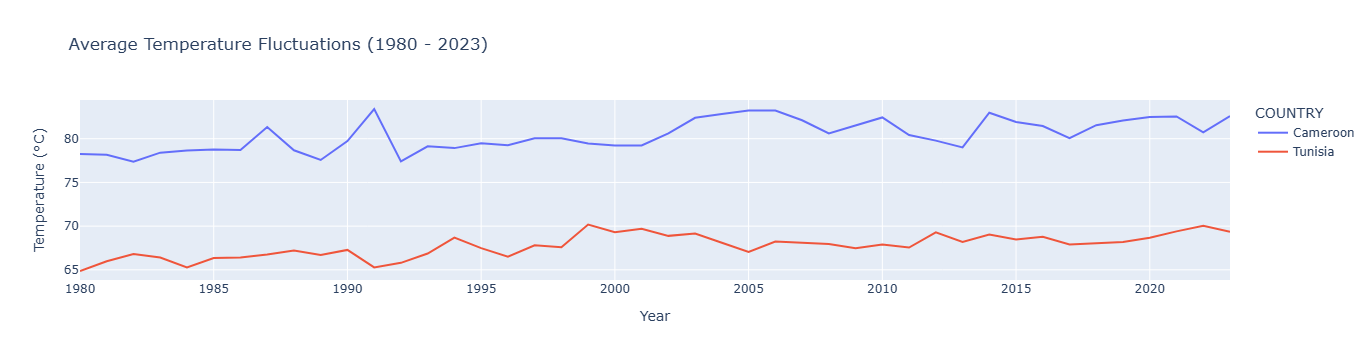

In [14]:
fig1 = px.line(
    df_annual_avg, 
    x='Year', 
    y='TAVG', 
    color='COUNTRY',
    title='Average Temperature Fluctuations (1980 - 2023)',
    labels={'TAVG': 'Temperature (°C)', 'Year': 'Year'}
)
fig1.show()

In [15]:
df_zoomed = df_annual_avg[(df_annual_avg['Year'] >= 1980) & (df_annual_avg['Year'] <= 2005)]

In [16]:
fig2 = px.line(
    df_zoomed, 
    x='Year', 
    y='TAVG', 
    color='COUNTRY',
    title='Zoomed In: Temperature Trends (1980 - 2005)',
    labels={'TAVG': 'Observed Mean Temperature (°C)', 'Year': 'Timeline (Years)'}
)


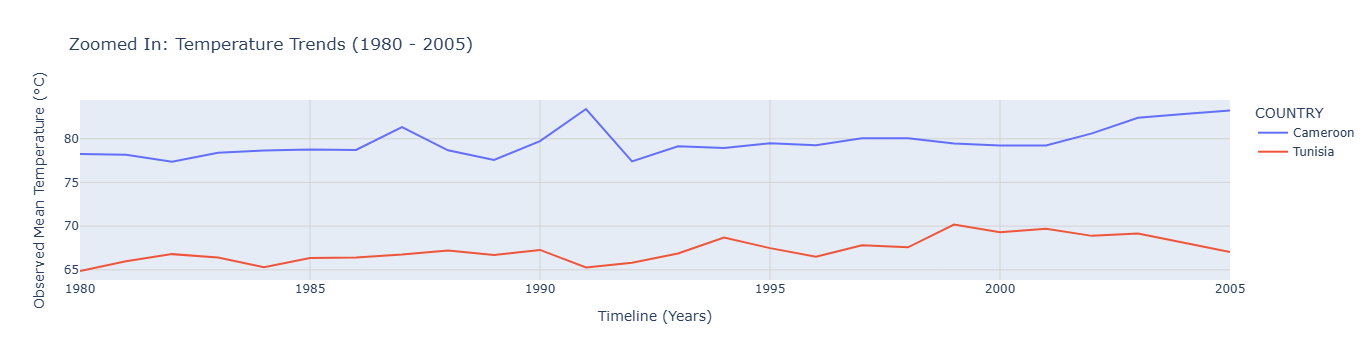

In [17]:
fig2.update_xaxes(dtick=5, gridcolor='LightGray')
fig2.update_yaxes(gridcolor='LightGray')

fig2.show()

In [18]:
df_senegal = df[df['COUNTRY'] == 'Senegal']

In [19]:
year_1980_2000 = df_senegal[(df_senegal['Year'] >= 1980) & (df_senegal['Year'] <= 2000)]
year_2001_2023 = df_senegal[(df_senegal['Year'] > 2000) & (df_senegal['Year'] <= 2023)]

In [20]:
mean_old = era_1980_2000['TAVG'].mean()
mean_new = era_2001_2023['TAVG'].mean()

NameError: name 'era_1980_2000' is not defined

In [ ]:
plt.figure(figsize=(10, 6))


In [ ]:
sns.histplot(year_1980_2000['TAVG'], color="skyblue", label="1980-2000 Era", alpha=0.6)
sns.histplot(year_2001_2023['TAVG'], color="orange", label="2001-2023 Era", alpha=0.5)
plt.axvline(mean_old, linestyle="--", label=f"Mean 1980-2000 ({mean_old:.1f}°C)", color="blue")
plt.axvline(mean_new, linestyle="--", label=f"Mean 2001-2023 ({mean_new:.1f}°C)", color="red")
plt.title("Senegal Temperature Distribution Across Eras")
plt.xlabel("Daily Average Temperature (°C)")
plt.ylabel("Count")
plt.legend()

In [ ]:
df_country_avg = df.groupby('COUNTRY')['TAVG'].mean().reset_index()
df_country_avg = df_country_avg.sort_values(by='TAVG', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_country_avg, x='COUNTRY', y='TAVG', hue='COUNTRY', palette='coolwarm', legend=False)
for index, row in df_country_avg.iterrows():
    plt.text(index, row['TAVG'] + 0.3, f"{row['TAVG']:.1f}°C", color='black', ha="center", fontweight='bold')
    plt.title("Overall Average Temperature per Country (1980-2023)", fontsize=14, fontweight='bold')
    plt.title("Overall Average Temperature per Country (1980-2023)", fontsize=14, fontweight='bold')


plt.show()

In [ ]:
print(df.info())
df.head()